In [1]:
# Import libraries
import numpy as np
import pandas as pd
import seaborn as sns
from boruta import BorutaPy
from sklearn.svm import SVC
from sklearn.metrics import *
import matplotlib.pyplot as plt
import tensorflow as tf, keras
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from scipy.stats import pointbiserialr
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import chi2
from sklearn.compose import ColumnTransformer
# from scikeras.wrappers import KerasClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, PolynomialFeatures
from sklearn.model_selection import train_test_split, GridSearchCV, RepeatedStratifiedKFold, StratifiedKFold
from sklearn.feature_selection import (SelectKBest, chi2, VarianceThreshold, mutual_info_classif, SequentialFeatureSelector, mutual_info_classif)
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, precision_score, f1_score, average_precision_score, 
                             PrecisionRecallDisplay, precision_recall_curve, roc_auc_score, recall_score, cohen_kappa_score)

2026-01-09 14:43:12.198057: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-09 14:43:12.353087: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-09 14:43:19.804324: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
df_children = pd.read_spss('/workspaces/malnutrition/models/models_new/NPKR82FL.SAV')
df_children.shape

(5372, 1422)

In [3]:
df_selected = df_children[['B19', 'B4', 'BORD', 'H22', 'H11', 'H31','H33','H43','M4','M34','V411A','M70','V410', 'M60', 'V012','V106','V717',
                        'V445','V312','V405','M14', 'M45', 'V130', 'V701', 'V151','V190','V136','V137','V024', 'V025', 'V113','V116','V161',
                        'V465','V467D','V481','V459', 'HW70','HW71','HW72', 'V463Z', 'V131', 'V212','V457', 'H80A', 'HW57']]
# Rename the variables
df1 = df_selected.rename(columns={
    'B19': 'Child Age', 
    'B4': 'Child Sex', 
    'BORD': 'Birth Order', 
    # 'B0': 'Birth Type', highly imbalance
    'H22': 'Fever', 
    'H11':'Diarrhea', 
    'H31': 'Cough',
    'H33': 'Vitamin A',
    # 'H42':'Iron to Child', NULL 
    'H43':'Parasite Deworm',
    'M4':'Breastfeeding',
    'M34':'First Breastfeed Duration', 
    'V411A':'Infant Formula',
    'M70': 'Postnatal Checkup',
    'V410':'Juice Intake', 
    'M60' : 'Mother Deworm',
    'V012':'Mother Age',
    'V106': 'Mother Education',
    'V717': 'Mother Occupation',
    'V445':'Mother BMI',
    'V312': 'Contraceptive Method',
    'V405': 'Amenorrhea',
    # 'V201': 'Child Ever Born', multicolinear with Birth Order
    'M14': 'Antenatal Care',
    'M45': 'Iron During Pregnancy', 
    # 'M49X': 'Malaria Deworm', NULL 
    # 'V501': 'Marital Status', highly imbalance 
    'V130': 'Religion', 
    'V701': 'Father Education', 
    'V151': 'Head Sex',
    'V190': 'Wealth Index',
    'V136': 'Household Size',
    'V137': 'No of Child',
    'V024': 'Province',
    'V025': 'Region',
    'V113': 'Water Source',
    'V116': 'Toilet Facility',
    'V161': 'Fuel Type',
    'V465': 'Stool Disposal',
    'V467D': 'Hospital Distance',
    'V481': 'Insurance',
    'V459': 'Bednet', 
    'HW70': 'Stunting',
    'HW71': 'Underweight',
    'HW72': 'Wasting', 
    'V463Z': 'Smoke', 
    # 'H15E': 'Zinc', Only 522 observation
    'V131': 'Ethnicity', 
    # 'M19': 'Birth Weight',  
    'V212': 'Age First Birth',
    'V457': 'Mother Anemia',
    'H80A': 'Micronutrient Powder',
    'HW57': 'Child Anemia'
})

df1.head(2)

,Child Age,Child Sex,Birth Order,Fever,Diarrhea,Cough,Vitamin A,Parasite Deworm,Breastfeeding,First Breastfeed Duration,...,Bednet,Stunting,Underweight,Wasting,Smoke,Ethnicity,Age First Birth,Mother Anemia,Micronutrient Powder,Child Anemia
0,41.0,Female,4.0,No,No,No,NaN,Yes,NaN,NaN,...,No,NaN,NaN,NaN,No,Hill Janajati,17.0,NaN,No,NaN
1,28.0,Female,2.0,Yes,No,"Yes, last two weeks",Reported by mother,Yes,Still breastfeeding,Hours: 1,...,No,NaN,NaN,NaN,"Yes, smokes nothing",Hill Chhetri,30.0,NaN,No,NaN


In [4]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5372 entries, 0 to 5371
Data columns (total 46 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   Child Age                  5372 non-null   float64 
 1   Child Sex                  5372 non-null   category
 2   Birth Order                5372 non-null   float64 
 3   Fever                      5205 non-null   category
 4   Diarrhea                   5205 non-null   category
 5   Cough                      5205 non-null   category
 6   Vitamin A                  3091 non-null   category
 7   Parasite Deworm            5205 non-null   category
 8   Breastfeeding              3177 non-null   category
 9   First Breastfeed Duration  3131 non-null   category
 10  Infant Formula             2707 non-null   category
 11  Postnatal Checkup          2942 non-null   category
 12  Juice Intake               2707 non-null   category
 13  Mother Deworm              2942 n

### Remove Unwanted Entries

In [5]:
# Clean up all string columns: strip whitespace and unify capitalization
df1 = df1.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# Define unwanted entries
unwanted = ["Don't know", "Flagged cases", "flagged cases", "don’t know", "Not a dejure resident", 
            "Composting toilet", "Flush, don't know where", "Gasoline/diesel", "Not weighed at birth"]

# Create a combined boolean mask for rows containing unwanted entries
mask = (
    df1['Fever'].isin(unwanted) |
    df1['Diarrhea'].isin(unwanted) |
    df1['Cough'].isin(unwanted) |
    df1['Parasite Deworm'].isin(unwanted) |
    df1['Toilet Facility'].isin(unwanted) |
    df1['Fuel Type'].isin(unwanted) |
    df1['Mother BMI'].isin(unwanted) |
    df1['Mother Deworm'].isin(unwanted) |
    df1['Antenatal Care'].isin(unwanted) |
    # df1['Birth Weight'].isin(unwanted) |
    df1['Micronutrient Powder'].isin(unwanted)
    
)

# Filter out those rows
df2 = df1[~mask].copy()

cat_cols = df2.select_dtypes(['category']).columns.tolist()
for col in cat_cols:
    df2[col] = df2[col].cat.remove_unused_categories()

df2.shape

(4828, 46)

### Handling missing variables

In [17]:
# df3 = df2.dropna(subset=['Wasting', 'Stunting', 'Underweight']) # Missing values in target variables are dropped 
df2.isna().sum().sort_values(ascending=False)

Child Anemia                 2685
Infant Formula               2451
Stool Disposal               2451
Juice Intake                 2451
Wasting                      2448
Stunting                     2448
Underweight                  2443
Mother Anemia                2337
Mother BMI                   2327
Iron During Pregnancy        2241
Postnatal Checkup            2241
Mother Deworm                2241
Antenatal Care               2241
Vitamin A                    2106
First Breastfeed Duration    2069
Breastfeeding                2029
Diarrhea                      155
Micronutrient Powder          155
Cough                         155
Fever                         155
Parasite Deworm               155
Father Education               41
Child Sex                       0
Child Age                       0
Birth Order                     0
Contraceptive Method            0
Mother Occupation               0
Mother Education                0
Amenorrhea                      0
Mother Age    

In [101]:
# Drop high-missing variables
high_missing = [
    'Infant Formula', 'Juice Intake', 'Stool Disposal', 'Postnatal Checkup', 'First Breastfeed Duration', 'Vitamin A', 'Child Anemia', 'Stunting', 'Wasting',  'Antenatal Care', 
    'Iron During Pregnancy', 'Mother Deworm', 'Breastfeeding', 'Contraceptive Method'
]
df4 = df2.drop(columns=high_missing)

# Drop missing entries from the following variables
df5 = df4.dropna(subset=['Father Education', 'Mother Anemia', 'Underweight']).copy()

print(df5.shape)
# df5.isna().sum().sort_values(ascending=False)

(2351, 32)


In [96]:
# Create Nutrition Status (combine all indicators)
cols = ['Underweight']
df5[cols] = df5[cols].apply(pd.to_numeric, errors='coerce')

import numpy as np

df5['Underweight_status'] = np.where(
    (df5['Underweight'] < -200) | (df5['Underweight'] > 200),
    'Malnourished',
    'Nourished'
)

df5 = df5.drop(columns=['Underweight'])

# # Drop the original indicator columns
# df6 = df5.drop(columns=['Stunting', 'Underweight', 'Wasting'])
# df6.shape

In [97]:
# Convert all categorical columns to numeric codes
cat_cols = df5.select_dtypes(include='category').columns

df5[cat_cols] = df5[cat_cols].apply(lambda x: x.cat.codes)

df5['Underweight_status'] = df5['Underweight_status'].map({
    'Nourished': 0,
    'Malnourished': 1
})


In [98]:
df5['Underweight_status'].value_counts()

Underweight_status
0    1876
1     475
Name: count, dtype: int64

In [99]:
df5.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2351 entries, 3 to 5369
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Child Age             2351 non-null   float64
 1   Child Sex             2351 non-null   int8   
 2   Birth Order           2351 non-null   float64
 3   Fever                 2351 non-null   int8   
 4   Diarrhea              2351 non-null   int8   
 5   Cough                 2351 non-null   int8   
 6   Parasite Deworm       2351 non-null   int8   
 7   Mother Age            2351 non-null   float64
 8   Mother Education      2351 non-null   int8   
 9   Mother Occupation     2351 non-null   int8   
 10  Mother BMI            2351 non-null   int16  
 11  Amenorrhea            2351 non-null   int8   
 12  Religion              2351 non-null   int8   
 13  Father Education      2351 non-null   int8   
 14  Head Sex              2351 non-null   int8   
 15  Wealth Index          2351

In [100]:
df5 = df5.apply(pd.to_numeric, errors='coerce')

X = df5.drop(columns=['Underweight_status'])
y = df5['Underweight_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)


# =====================
# 2. Base Model with SMOTE outside pipeline
# =====================
base_lr = LogisticRegression(solver='liblinear', random_state=42)
base_lr.fit(X_train_sm, y_train_sm)

y_pred_base = base_lr.predict(X_test)
y_proba_base = base_lr.predict_proba(X_test)[:, 1]
y_train_pred_base = base_lr.predict(X_train_sm)

# Evaluation
print(confusion_matrix(y_test, y_pred_base))
print("------------------------------------------------------")
print(classification_report(y_test, y_pred_base, digits=3))
print("------------------------------------------------------")
print(f"Test Avg Precision: {average_precision_score(y_test, y_proba_base):.3f}")
print(f"Test AUC: {roc_auc_score(y_test, y_proba_base):.3f}")
print(f"Test Cohen's Kappa: {cohen_kappa_score(y_test, y_pred_base):.3f}")
print(f"Training recall: {recall_score(y_train_sm, y_train_pred_base):.3f}")

[[290  86]
 [ 61  34]]
------------------------------------------------------
              precision    recall  f1-score   support

           0      0.826     0.771     0.798       376
           1      0.283     0.358     0.316        95

    accuracy                          0.688       471
   macro avg      0.555     0.565     0.557       471
weighted avg      0.717     0.688     0.701       471

------------------------------------------------------
Test Avg Precision: 0.261
Test AUC: 0.584
Test Cohen's Kappa: 0.118
Training recall: 0.760


In [75]:
from collections import Counter

print("Before SMOTE:", Counter(y_train))
print("After SMOTE:", Counter(y_train_sm))

Before SMOTE: Counter({0: 824, 1: 202})
After SMOTE: Counter({0: 824, 1: 824})


In [29]:
print(df_children.shape)
print(df5.shape)

(5372, 1422)
(1279, 40)


### Imputing Missing entries

In [10]:
# Antenatal Care
df5['Antenatal Care'] = df5['Antenatal Care'].astype(str).replace({'No antenatal visits': 0}).astype(float)
df5['Antenatal Care'] = df5['Antenatal Care'].clip(upper=10) # Cap outliers (anything above 10 visits)
median_anc = df5.loc[df5['Antenatal Care'] > 0, 'Antenatal Care'].median() # Impute missing values with median among valid numeric values
df5['Antenatal Care'] = df5['Antenatal Care'].fillna(median_anc)

# Breastfeeding
# Encode current vs ever vs never
bf_map = {
    'Still breastfeeding': 2,                 # currently breastfeeding
    'Ever breastfed, not currently breastfeeding': 1,  # has breastfed before
    'Never breastfed': 0                      # never breastfed
}
df5['Breastfeeding'] = df5['Breastfeeding'].astype(str).replace(bf_map).astype(float)
mode_bf = df5['Breastfeeding'].mode()[0] # Impute with mode (most likely = still breastfeeding)
df5['Breastfeeding'] = df5['Breastfeeding'].fillna(mode_bf)


# # Iron During Pregnancy
# # Simple binary encoding
# iron_map = {'Yes': 1, 'No': 0}
# df5['Iron During Pregnancy'] = df5['Iron During Pregnancy'].astype(str).replace(iron_map).astype(float)
# mode_iron = df5['Iron During Pregnancy'].mode()[0] # Impute missing with mode (majority took iron)
# df5['Iron During Pregnancy'] = df5['Iron During Pregnancy'].fillna(mode_iron)

# Mother Deworm
# Simple binary encoding
md_map = {'Yes': 1, 'No': 0}
df5['Mother Deworm'] = df5['Mother Deworm'].astype(str).replace(md_map).astype(float)
mode_md = df5['Mother Deworm'].mode()[0] # Impute missing with mode
df5['Mother Deworm'] = df5['Mother Deworm'].fillna(mode_md)

# # Birth Weight
# df5['Birth Weight'] = pd.to_numeric(df5['Birth Weight'], errors='coerce')
# median_bw = df5['Birth Weight'].median() # Impute missing with median of measured weights
# df5['Birth Weight'] = df5['Birth Weight'].fillna(median_bw)

In [11]:
df5.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2347 entries, 3 to 5369
Data columns (total 40 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   Child Age              2347 non-null   float64 
 1   Child Sex              2347 non-null   category
 2   Birth Order            2347 non-null   float64 
 3   Fever                  2347 non-null   category
 4   Diarrhea               2347 non-null   category
 5   Cough                  2347 non-null   category
 6   Parasite Deworm        2347 non-null   category
 7   Breastfeeding          2347 non-null   float64 
 8   Mother Deworm          2347 non-null   float64 
 9   Mother Age             2347 non-null   float64 
 10  Mother Education       2347 non-null   category
 11  Mother Occupation      2347 non-null   category
 12  Mother BMI             2347 non-null   category
 13  Contraceptive Method   2347 non-null   category
 14  Amenorrhea             2347 non-null   catego

### Combine Malnutrition Status

In [12]:
# Create Nutrition Status (combine all indicators)
cols = ['Stunting', 'Underweight', 'Wasting']
df5[cols] = df5[cols].apply(pd.to_numeric, errors='coerce')

df5['Nutrition Status'] = df5[['Stunting', 'Underweight', 'Wasting']].apply(
    lambda x: 'Malnourished' if any(v < -200 or v > 200 for v in x) else 'Nourished',
    axis=1
)

# Drop the original indicator columns
df6 = df5.drop(columns=['Stunting', 'Underweight', 'Wasting'])
df6.shape

(2347, 38)

In [13]:
for col in df6.columns:
    print('-' * 30)
    print(f'Value counts for {col}:')
    print('-' * 30)
    print(df6[col].value_counts())  

------------------------------
Value counts for Child Age:
------------------------------
Child Age
38.0    66
15.0    57
26.0    56
32.0    51
55.0    51
41.0    50
30.0    49
29.0    48
51.0    47
5.0     47
28.0    46
59.0    46
37.0    45
49.0    42
40.0    42
16.0    42
35.0    41
52.0    41
13.0    41
50.0    41
25.0    41
19.0    40
42.0    39
43.0    39
48.0    39
27.0    38
46.0    38
54.0    38
33.0    38
39.0    37
14.0    37
0.0     37
22.0    37
58.0    36
21.0    36
36.0    36
34.0    36
6.0     35
45.0    35
56.0    35
31.0    35
18.0    35
8.0     35
4.0     35
12.0    35
20.0    34
11.0    34
47.0    34
57.0    34
44.0    33
17.0    33
24.0    33
23.0    33
7.0     33
9.0     33
1.0     32
3.0     30
2.0     27
53.0    27
10.0    26
Name: count, dtype: int64
------------------------------
Value counts for Child Sex:
------------------------------
Child Sex
Male      1229
Female    1118
Name: count, dtype: int64
------------------------------
Value counts for Birth Orde

Birth Order
1.0     899
2.0     777
3.0     353
4.0     193
5.0      73
6.0      34
7.0      11
8.0       3
10.0      2
9.0       2
Name: count, dtype: int64
------------------------------
Value counts for Fever:
------------------------------
Fever
No     1765
Yes     582
Name: count, dtype: int64
------------------------------
Value counts for Diarrhea:
------------------------------
Diarrhea
No                     2092
Yes, last two weeks     255
Name: count, dtype: int64
------------------------------
Value counts for Cough:
------------------------------
Cough
No                     1575
Yes, last two weeks     772
Name: count, dtype: int64
------------------------------
Value counts for Parasite Deworm:
------------------------------
Parasite Deworm
Yes    1687
No      660
Name: count, dtype: int64
------------------------------
Value counts for Breastfeeding:
------------------------------
Breastfeeding
2.0    2175
1.0     168
0.0       4
Name: count, dtype: int64
--------------

#### Ethnicity Categories
* Groups “Hill Brahmin” + “Hill Chhetri”: `Hill Brahmin/Chhetri`
* Keeps “Hill Dalit”: `Hill Dalit`
* Groups “Hill Janajati” + “Newar”: `Hill Janajati`
* Groups “Terai Brahmin/Chhetri” + “Other Terai caste”: `Terai Caste`
* Groups “Terai Janajati”, “Terai Dalit”, “Muslim”, “Other”: `Other`

#### Toilet Facility
* `Improved sanitation`: Flush to piped sewer system, Flush to septic tank, Flush to pit latrine, Biogas attached toilet, Ventilated Improved Pit latrine (VIP), Pit latrine with slab
* `Unimproved sanitation`: Pit latrine without slab/open pit, Flush to somewhere else, Composting toilet without slab, Other, No facility/bush/field

#### Mother Occupation
* 'Agricultural - self employed': 'Agricultural',
* 'Not working': 'Not working',
* 'Professional/technical/managerial' + 'Skilled manual' + 'Sales' + 'Clerical': 'Professional',
* 'Unskilled manual' + 'Other': 'Other'

#### Mother BMI
   * 'Underweight': 'Underweight',
   * 'Normal': 'Normal',
   * 'Overweight': 'Overweight',
   * 'Obese': 'Overweight'

### Categorization

In [14]:
df = df6.copy()

# Child Age in month intervals
child_bins = [6, 12, 24, 36, 48, 60]  # upper bound is exclusive
child_labels = ['6-12', '13-24', '25-36', '37-48', '49-59']
df['Child Age'] = pd.cut(df['Child Age'], bins=child_bins, labels=child_labels, right=False)

# Define grouping function
def categorize_mother_age(age):
    if pd.isna(age):
        return 'Unknown'
    elif age < 20:
        return 'Teenage (<20)'
    elif 20 <= age <= 29:
        return 'Young adult (20-29)'
    elif 30 <= age <= 39:
        return 'Adult (30-39)'
    else:
        return 'Older (40+)'
df['Mother Age'] = df['Mother Age'].apply(categorize_mother_age)

# Mother BMI
df['Mother BMI'] = pd.to_numeric(df['Mother BMI'], errors='coerce')/100 # Convert to numeric safely
bmi_bins = [0, 18.5, 24.9, 29.9, np.inf]
bmi_labels = ['Underweight', 'Normal', 'Overweight', 'Obese']
df['Mother BMI'] = pd.cut(df['Mother BMI'], bins=bmi_bins, labels=bmi_labels, right=False)

# Ethnicity
ethnicity_map = {
    'Hill Brahmin': 'Hill Brahmin/Chhetri',
    'Hill Chhetri': 'Hill Brahmin/Chhetri',
    'Hill Dalit': 'Hill Dalit',
    'Hill Janajati': 'Hill Janajati',
    'Newar': 'Hill Janajati',
    'Terai Brahmin/Chhetri': 'Terai Caste',
    'Other Terai caste': 'Terai Caste',
    'Terai Janajati': 'Other',
    'Terai Dalit': 'Other',
    'Muslim': 'Other',
    'Other': 'Other'
}
df['Ethnicity'] = df['Ethnicity'].astype(str).replace(ethnicity_map)
df['Ethnicity'] = df['Ethnicity'].replace(ethnicity_map)

# Toilet Facility
toilet_map = {
    # Improved
    'Flush to piped sewer system': 'Improved Toilet',
    'Flush to septic tank': 'Improved Toilet',
    'Flush to pit latrine': 'Improved Toilet',
    'Biogas attached toilet': 'Improved Toilet',
    'Ventilated Improved Pit latrine (VIP)': 'Improved Toilet',
    'Pit latrine with slab': 'Improved Toilet',

    # Unimproved
    'Pit latrine without slab/open pit': 'Unimproved Toilet',
    'Flush to somewhere else': 'Unimproved Toilet',
    'Composting toilet without slab': 'Unimproved Toilet',
    'Other': 'Unimproved Toilet',
    'No facility/bush/field': 'Unimproved Toilet'
}
df['Toilet Facility'] = df['Toilet Facility'].astype(str).replace(ethnicity_map)
df['Toilet Facility'] = df['Toilet Facility'].replace(toilet_map)

# Group Mother Occupation
occupation_map = {
    'Agricultural - self employed': 'Agricultural',
    'Not working': 'Not working',
    'Sales': 'Professional',
    'Professional/technical/managerial': 'Professional',
    'Unskilled manual': 'Other',
    'Skilled manual': 'Professional',
    'Clerical': 'Professional',
    'Other': 'Other'
}
df['Mother Occupation'] = df['Mother Occupation'].astype(str).replace(occupation_map)
df['Mother Occupation'] = df['Mother Occupation'].replace(occupation_map)

# Group Mother BMI
bmi_map = {
    'Underweight': 'Underweight',
    'Normal': 'Normal',
    'Overweight': 'Overweight',
    'Obese': 'Overweight'
}
df['Mother BMI'] = df['Mother BMI'].astype(str).replace(occupation_map)
df['Mother BMI'] = df['Mother BMI'].replace(bmi_map)

# Map contraceptive method
contraceptive_map = {
    'Not using': 'Non-user',
    'Injections': 'User',
    'Withdrawal': 'User',
    'Implants': 'User',
    'Female sterilization': 'User',
    'Pill': 'User',
    'Male condom': 'User',
    'Periodic abstinence': 'User',
    'IUD': 'User',
    'Male sterilization': 'User',
    'Lactational amenorrhea (LAM)': 'User',
    'Emergency contraception': 'User',
    'Other traditional': 'User'
}
df['Contraceptive Method'] = df['Contraceptive Method'].astype(str).replace(occupation_map)
df['Contraceptive Method'] = df['Contraceptive Method'].replace(contraceptive_map)

# Birth Order
def categorize_birth_order(n):
    if n == 1:
        return 'First'
    elif n == 2:
        return 'Second'
    else:
        return 'Third+'
df['Birth Order'] = df['Birth Order'].apply(categorize_birth_order)

# Religion
def categorize_religion(r):
    if r == 'Hindu':
        return 'Hindu'
    else:
        return 'Non-Hindu'

df['Religion'] = df['Religion'].apply(categorize_religion)

# Father Education
def categorize_father_education(ed):
    if ed in ['No education', "Don't know"]:
        return 'No education'
    elif ed in ['Basic']:
        return 'Basic'
    elif ed == 'Secondary':
        return 'Secondary'
    elif ed == 'Higher':
        return 'Higher'

df['Father Education'] = df['Father Education'].apply(categorize_father_education)

# Wealth Index
wealth_map = {
    'Poorest': 'Low',
    'Poorer': 'Low',
    'Middle': 'Middle',
    'Richer': 'High',
    'Richest': 'High'
}
df['Wealth Index'] = df['Wealth Index'].astype(str).replace(wealth_map)
df['Wealth Index'] = df['Wealth Index'].replace(wealth_map)

# Household Size
def categorize_household_size(size):
    if size <= 4:
        return 'Small'
    elif 5 <= size <= 8:
        return 'Medium'
    else:
        return 'Large'
df['Household Size'] = df['Household Size'].apply(categorize_household_size)

# Number of Child
def categorize_no_of_child(n):
    if n <= 2:
        return 'Few (0-2)'
    else:
        return 'Many (3+)'

df['No of Child'] = df['No of Child'].apply(categorize_no_of_child)

# Water Source
def categorize_water_source(source):
    improved = [
        'Tube well or borehole', 'Piped to yard/plot', 'Piped into dwelling',
        'Public tap/standpipe', 'Bottled water', 'Protected spring', 'Protected well'
    ]
    if source in improved:
        return 'Improved Water'
    else:
        return 'Unimproved Water'

df['Water Source'] = df['Water Source'].apply(categorize_water_source)

# Fuel Type
def categorize_fuel(fuel):
    clean = [
        'Liquefied petroleum gas (LPG)/cooking gas', 'Electricity', 
        'Solar energy', 'Biogas', 'Piped natural gas'
    ]
    if fuel in clean:
        return 'Clean Fuel'
    else:
        return 'Unclean Fuel'

df['Fuel Type'] = df['Fuel Type'].apply(categorize_fuel)


# Does not Smoke
def categorize_smoke(smoke):
    if smoke == "Yes, smokes nothing":
        return "No"
    else:
        return "Yes"

df['Smoke'] = df['Smoke'].apply(categorize_smoke)

# Age First Birth
def categorize_age_first_birth(age):
    if age < 20:
        return 'Teenage (<20)'
    elif 20 <= age <= 29:
        return 'Young adult (20-29)'
    else:
        return 'Older (30+)'
df['Age First Birth'] = df['Age First Birth'].apply(categorize_age_first_birth)

# Mother Anemia
anemia_map = {
    'Not anemic': 'Not anemic',
    'Mild (NP 11.0-11.9 g/dl / P 10.0-10.9 g/dl)': 'Anemic',
    'Moderate (NP 8-10.9 g/dl / P 7.0-9.9 g/dl)': 'Anemic',
    'Severe (NP < 8.0 g/dl / P < 7.0 g/dl)': 'Anemic'
}
df['Mother Anemia'] = df['Mother Anemia'].astype(str).replace(anemia_map)
df['Mother Anemia'] = df['Mother Anemia'].replace(anemia_map)

# Mapping for Child Anemia
child_anemia_map = {
    'Not anemic': 'Not anemic',
    'Mild': 'Anemic',
    'Moderate': 'Anemic',
    'Severe': 'Anemic'
}
df['Child Anemia'] = df['Child Anemia'].astype(str).replace(child_anemia_map)

# Breastfeeding
def categorize_breastfeeding(x):
    if x == 2:
        return 'Yes'
    else:
        return 'No'

df['Breastfeeding'] = df['Breastfeeding'].apply(categorize_breastfeeding)

# Antenatal Care
def categorize_anc(x):
    if x < 4:
        return 'Inadequate ANC'
    else:
        return 'Adequate ANC'
df['Antenatal Care'] = df['Antenatal Care'].apply(categorize_anc)

# Iron During Pregnancy
iron_map = {
    1.0: 'Yes',
    0.0: 'No'
}

df['Iron During Pregnancy'] = df['Iron During Pregnancy'].replace(iron_map)

# Birth Weight
def categorize_birth_weight(w):
    if w < 2500:
        return 'Low'
    elif 2500 <= w < 4000:
        return 'Normal'
    else:
        return 'High'

df['Birth Weight'] = df['Birth Weight'].apply(categorize_birth_weight)

KeyError: 'Birth Weight'

In [ ]:
df['Mother Deworm'].value_counts()

Mother Deworm
1.0    1871
0.0     182
Name: count, dtype: int64

### Value Counts

In [ ]:
for col in df.columns:
    print('-' * 30)
    print(f'Value counts for {col}:')
    print('-' * 30)
    print(df[col].value_counts())

------------------------------
Value counts for Child Age:
------------------------------
Child Age
37-48    494
49-59    477
25-36    388
13-24    356
6-12     168
Name: count, dtype: int64
------------------------------
Value counts for Child Sex:
------------------------------
Child Sex
Male      1085
Female     968
Name: count, dtype: int64
------------------------------
Value counts for Birth Order:
------------------------------
Birth Order
First     849
Second    681
Third+    523
Name: count, dtype: int64
------------------------------
Value counts for Fever:
------------------------------
Fever
No     1531
Yes     522
Name: count, dtype: int64
------------------------------
Value counts for Diarrhea:
------------------------------
Diarrhea
No                     1834
Yes, last two weeks     219
Name: count, dtype: int64
------------------------------
Value counts for Cough:
------------------------------
Cough
No                     1364
Yes, last two weeks     689
Name: count

In [ ]:
# df.to_csv(r'C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Anemia\Methods\anemia_prediction\data\df_imputed.csv', index=False)

## Contengency Table

In [ ]:
target= "Child Anemia"
features = [
    'Child Age', 'Fever', 'Household Size', 'Mother Anemia',
       'Parasite Deworm', 'Amenorrhea', 'Province',
       'Antenatal Care', 'Mother Deworm', 'Breastfeeding'
]

def contingency_table_with_total_pct(df, feature,  total_label="Total"):
    """
    Build a contingency table where every cell shows "count (pct_of_total%)".
    - df: DataFrame
    - feature: categorical variable name (string)
    - target: target column name (string)
    - total_label: label for the total column
    Returns a DataFrame of strings.
    """
    # defensive copy / clean index
    df = df.reset_index(drop=True)

    # total counts per category (rows)
    total = df[feature].value_counts().sort_index()
    total_pct = (total / len(df) * 100).round(1)

    # contingency counts: rows = categories, cols = target values
    ct = pd.crosstab(df[feature], df[target]).reindex(total.index, fill_value=0)

    # build output DataFrame
    out = pd.DataFrame(index=total.index)

    # Total column: count (pct_of_total%)
    out[total_label] = total.astype(str) + " (" + total_pct.astype(str) + "%)"

    # For each target class, show count (pct_of_total%)
    for col in ct.columns:
        col_counts = ct[col]
        col_pct_of_total = (col_counts / len(df) * 100).round(1)
        # label the target columns using the target values (you can map 0/1 -> names if you want)
        out[f"{col}"] = col_counts.astype(str) + " (" + col_pct_of_total.astype(str) + "%)"

    return out

# Generate Table for All Variables Automatically
tables = {}

for var in features:
    tables[var] = contingency_table_with_total_pct(df, var, target)

for var, table in tables.items():
    print(f"Contingency Table for {var}:")
    print(table)
    print("\n")

Contingency Table for Child Age:
          Child Anemia       Anemic   Not anemic       nan
Child Age                                                 
6-12        168 (8.2%)   125 (6.1%)    41 (2.0%)  2 (0.1%)
13-24      356 (17.3%)  213 (10.4%)   134 (6.5%)  9 (0.4%)
25-36      388 (18.9%)   160 (7.8%)  226 (11.0%)  2 (0.1%)
37-48      494 (24.1%)   154 (7.5%)  332 (16.2%)  8 (0.4%)
49-59      477 (23.2%)   118 (5.7%)  352 (17.1%)  7 (0.3%)


Contingency Table for Fever:
       Child Anemia       Anemic   Not anemic         nan
Fever                                                    
No     1531 (74.6%)  540 (26.3%)  835 (40.7%)  156 (7.6%)
Yes     522 (25.4%)  230 (11.2%)  250 (12.2%)   42 (2.0%)


Contingency Table for Household Size:
                Child Anemia       Anemic   Not anemic         nan
Household Size                                                    
Large            239 (11.6%)   100 (4.9%)   104 (5.1%)   35 (1.7%)
Medium          1099 (53.5%)  415 (20.2%)  568 (27

___

### Encoding

In [ ]:
# Define feature groups (NAMES only)
ordinal_features = [
    'Child Age', 'Birth Order', 'Mother Age', 'Mother Education', 
    'Father Education', 'Mother BMI', 'Antenatal Care', 'Hospital Distance',
    'Wealth Index', 'Household Size', 'No of Child', 'Birth Weight', 
    'Age First Birth', 'Nutrition Status'
]

nominal_features = [
    'Province', 'Region', 'Mother Occupation', 'Water Source',
    'Toilet Facility', 'Fuel Type', 'Ethnicity'
]

binary_feature_names = [
    'Child Sex', 'Fever', 'Diarrhea', 'Cough', 'Parasite Deworm',
    'Breastfeeding', 'Contraceptive Method', 'Amenorrhea',
    'Iron During Pregnancy', 'Religion', 'Head Sex', 'Insurance',
    'Bednet', 'Smoke', 'Mother Anemia', 'Micronutrient Powder', 'Mother Deworm'
]

# Define explicit ordering for binary CATEGORIES (matching your actual data)
binary_categories = [
    ['Female', 'Male'],           # Child Sex
    ['No', 'Yes'],                # Fever
    ['No', 'Yes, last two weeks'], # Diarrhea
    ['No', 'Yes, last two weeks'], # Cough
    ['No', 'Yes'],                # Parasite Deworm
    ['No', 'Yes'],                # Breastfeeding
    ['Non-user', 'User'],         # Contraceptive Method
    ['No', 'Yes'],                # Amenorrhea
    ['No', 'Yes'],                # Iron During Pregnancy
    ['Non-Hindu', 'Hindu'],       # Religion
    ['Female', 'Male'],           # Head Sex
    ['No', 'Yes'],                # Insurance
    ['No', 'Yes'],                # Bednet
    ['No', 'Yes'],                # Smoke
    ['Not anemic', 'Anemic'],     # Mother Anemia
    ['No', 'Yes'],                # Micronutrient Powder
    [0.0, 1.0]                    # Mother Deworm
]

# Define ordered categories for ordinal variables
ordinal_categories = [
    ['6-12', '13-24', '25-36', '37-48', '49-59'],
    ['First', 'Second', 'Third+'],
    ['Teenage (<20)', 'Young adult (20-29)', 'Adult (30-39)', 'Older (40+)'],
    ['No education', 'Basic', 'Secondary', 'Higher'],
    ['No education', 'Basic', 'Secondary', 'Higher'],
    ['Underweight', 'Normal', 'Overweight'],
    ['Inadequate ANC', 'Adequate ANC'],
    ['Big problem', 'Not a big problem'],
    ['Low', 'Middle', 'High'],
    ['Small', 'Medium', 'Large'],
    ['Few (0-2)', 'Many (3+)'],
    ['Low', 'Normal', 'High'],
    ['Teenage (<20)', 'Young adult (20-29)', 'Older (30+)'],
    ['Malnourished', 'Nourished']
]

# Create transformers with dtype=float
ordinal_transformer = OrdinalEncoder(categories=ordinal_categories, dtype=float)
onehot_transformer = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
binary_transformer = OrdinalEncoder(categories=binary_categories, dtype=float)

# Combine transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('ord', ordinal_transformer, ordinal_features),
        ('onehot', onehot_transformer, nominal_features),
        ('binary', binary_transformer, binary_feature_names)
    ],
    remainder='drop'
)

# Prepare data
X = df.drop(columns=['Child Anemia'])
X_fit = preprocessor.fit_transform(X)

# Get feature names
ordinal_names = ordinal_features
onehot_names = preprocessor.named_transformers_['onehot'].get_feature_names_out(nominal_features)
binary_names = binary_feature_names

# Combine all feature names
encoded_feature_names = list(ordinal_names) + list(onehot_names) + list(binary_names)

# Convert to DataFrame
X_encoded = pd.DataFrame(X_fit, columns=encoded_feature_names)
y = df['Child Anemia'].map({'Not anemic': 0, 'Anemic': 1})

print(f"Original features: {X.shape[1]}")
print(f"Encoded features: {X_encoded.shape[1]}")

ValueError: Found unknown categories [nan] in column 0 during fit

# Feature Selection

## Chi-Square Test

In [ ]:
chi_vals, p_vals = chi2(X_encoded, y)

chi_df = pd.DataFrame({'Feature': X_encoded.columns, 'Chi2_score': chi_vals, 'p-value': p_vals})
print(chi_df.sort_values(by='Chi2_score', ascending=False))

                              Feature  Chi2_score       p-value
0                           Child Age  135.610532  2.427699e-31
29                    Ethnicity_Other   25.492725  4.440543e-07
45                      Mother Anemia   23.557673  1.212251e-06
35                    Parasite Deworm   16.622342  4.561057e-05
38                         Amenorrhea   13.611106  2.248514e-04
18          Province_Madhesh province   10.774561  1.029046e-03
16                     Province_Koshi    8.440004  3.670554e-03
32                              Fever    8.116141  4.387284e-03
28            Ethnicity_Hill Janajati    8.011619  4.647818e-03
10                        No of Child    7.250433  7.088392e-03
14          Province_Gandaki province    6.475418  1.093766e-02
17          Province_Lumbini province    4.771613  2.893271e-02
21      Mother Occupation_Not working    4.490773  3.407826e-02
9                      Household Size    4.187001  4.073509e-02
23     Mother Occupation_Professional   

## Mutual Information

In [ ]:
# Apply Mutual Information feature selection
mi_scores = mutual_info_classif(X_encoded, y, random_state=42)

# Get results
mi_results = pd.DataFrame({
    'Feature': X_encoded.columns,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

# Display results
print(mi_results.to_string(index=False))

                          Feature  MI_Score
                        Child Age  0.061412
                  Parasite Deworm  0.030864
                    Breastfeeding  0.027370
                         Religion  0.022654
                   Antenatal Care  0.020527
                    Mother Anemia  0.019809
                     Region_Urban  0.018308
            Iron During Pregnancy  0.017648
            Ethnicity_Terai Caste  0.017061
                       Mother Age  0.013139
                   Household Size  0.012274
                  Age First Birth  0.012049
                            Cough  0.011717
                            Fever  0.009902
                      Birth Order  0.009714
  Province_Sudurpashchim province  0.009204
                  Ethnicity_Other  0.008137
                         Diarrhea  0.007694
           Fuel Type_Unclean Fuel  0.007283
                 Father Education  0.005474
                 Nutrition Status  0.004752
    Mother Occupation_Not workin

## Point-Biserial Correlation

In [ ]:
# Apply Point-Biserial Correlation
pb_scores = []
pb_pvalues = []

for col in X_encoded.columns:
    corr, pval = pointbiserialr(X_encoded[col], y)
    pb_scores.append(abs(corr))  # Use absolute value for ranking
    pb_pvalues.append(pval)

# Get results
pb_results = pd.DataFrame({
    'Feature': X_encoded.columns,
    'PB_Correlation': pb_scores,
    'P_Value': pb_pvalues
}).sort_values('PB_Correlation', ascending=False)

# Display results
print(pb_results.to_string(index=False))

                          Feature  PB_Correlation      P_Value
                        Child Age        0.325454 5.053019e-47
                  Parasite Deworm        0.211956 2.763595e-20
                    Mother Anemia        0.138732 1.971488e-09
                  Ethnicity_Other        0.130890 1.531885e-08
                    Mother Deworm        0.094876 4.262680e-05
                       Amenorrhea        0.090306 9.827615e-05
        Province_Madhesh province        0.084640 2.627357e-04
                            Fever        0.076829 9.274594e-04
                   Province_Koshi        0.073437 1.550579e-03
          Ethnicity_Hill Janajati        0.073401 1.558756e-03
                           Bednet        0.065612 4.697920e-03
                      No of Child        0.065519 4.757434e-03
                   Household Size        0.064447 5.491154e-03
                   Antenatal Care        0.062818 6.801660e-03
        Province_Gandaki province        0.061681 7.876

## Boruta Algorithm

In [ ]:
# Convert to numpy arrays (Boruta requires numpy arrays)
X_np = X_encoded.values
y_np = y.values

# Define the RandomForest model for Boruta
rf = RandomForestClassifier(n_jobs=-1, class_weight='balanced', max_depth=5, random_state=42)

# Initialize Boruta
boruta_selector = BorutaPy(
    estimator=rf,
    n_estimators='auto',
    verbose=2,
    random_state=42
)

# Fit Boruta
boruta_selector.fit(X_np, y_np)

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	48
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	48
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	48
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	48
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	48
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	48
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	48
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	4
Tentative: 	4
Rejected: 	40
Iteration: 	9 / 100
Confirmed: 	4
Tentative: 	4
Rejected: 	40
Iteration: 	10 / 100
Confirmed: 	4
Tentative: 	4
Rejected: 	40
Iteration: 	11 / 100
Confirmed: 	4
Tentative: 	4
Rejected: 	40
Iteration: 	12 / 100
Confirmed: 	4
Tentative: 	3
Rejected: 	41
Iteration: 	13 / 100
Confirmed: 	4
Tentative: 	3
Rejected: 	41
Iteration: 	14 / 100
Confirmed: 	4
Tentative: 	3
Rejected: 	41
Iteration: 	15 / 100
Confirmed: 	4
Tentative: 	3
Rejected: 	41
Iteration: 	16 / 100
Confirmed: 	4
Tentative: 	3
Rejected: 	41
I

BorutaPy(estimator=RandomForestClassifier(class_weight='balanced', max_depth=5,
                                          n_estimators=63, n_jobs=-1,
                                          random_state=RandomState(MT19937) at 0x20FFB74F240),
         n_estimators='auto',
         random_state=RandomState(MT19937) at 0x20FFB74F240, verbose=2)

In [ ]:
# Get selected feature names
selected_features = X_encoded.columns[boruta_selector.support_].tolist()
print("Selected Features by Boruta:")
print(selected_features)

Selected Features by Boruta:
['Child Age', 'Father Education', 'Ethnicity_Other', 'Parasite Deworm', 'Mother Anemia']


In [ ]:
# Get feature rankings for all features
feature_ranks = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Rank': boruta_selector.ranking_
}).sort_values(by='Rank')

print(feature_ranks)

                              Feature  Rank
0                           Child Age     1
4                    Father Education     1
29                    Ethnicity_Other     1
35                    Parasite Deworm     1
45                      Mother Anemia     1
38                         Amenorrhea     2
32                              Fever     2
18          Province_Madhesh province     2
47                      Mother Deworm     4
9                      Household Size     5
3                    Mother Education     6
16                     Province_Koshi     7
28            Ethnicity_Hill Janajati     7
2                          Mother Age     9
11                       Birth Weight    10
5                          Mother BMI    11
43                             Bednet    12
36                      Breastfeeding    13
8                        Wealth Index    14
13                   Nutrition Status    15
14          Province_Gandaki province    17
10                        No of 

In [ ]:
# Get top 15 features from each method
chi_top15 = chi_df.sort_values(by='Chi2_score', ascending=False).head(15)['Feature'].tolist()
mi_top15 = mi_results.head(15)['Feature'].tolist()
pb_top15 = pb_results.head(15)['Feature'].tolist()
boruta_top15 = feature_ranks[feature_ranks['Rank'] <= 15]['Feature'].tolist()

# Get all unique features
all_features = set(chi_top15 + mi_top15 + pb_top15 + boruta_top15)

# Create comparison table
comparison_data = []
for feature in all_features:
    row = {
        'Feature': feature,
        'Chi-Square': '✓' if feature in chi_top15 else '',
        'Mutual Info': '✓' if feature in mi_top15 else '',
        'Point-Biserial': '✓' if feature in pb_top15 else '',
        'Boruta': '✓' if feature in boruta_top15 else '',
    }
    # Count how many methods selected this feature
    row['Count'] = sum([
        feature in chi_top15,
        feature in mi_top15,
        feature in pb_top15,
        feature in boruta_top15
    ])
    comparison_data.append(row)

# Create DataFrame and sort by count
comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values(['Count', 'Feature'], ascending=[False, True])

# Display
print("\n" + "="*80)
print("FEATURE SELECTION COMPARISON - TOP 15 FROM EACH METHOD")
print("="*80)
print(comparison_df.to_string(index=False))

# Show consensus features
print("\n" + "="*80)
print("CONSENSUS FEATURES (Selected by 3+ methods):")
print("="*80)
consensus = comparison_df[comparison_df['Count'] >= 3]['Feature'].tolist()
for i, feat in enumerate(consensus, 1):
    count = comparison_df[comparison_df['Feature'] == feat]['Count'].values[0]
    print(f"{i:2d}. {feat} ({count}/4 methods)")

print(f"\nTotal consensus features: {len(consensus)}")

# Show strong consensus (all 4 methods)
print("\n" + "="*80)
print("STRONG CONSENSUS (Selected by all 4 methods):")
print("="*80)
strong_consensus = comparison_df[comparison_df['Count'] == 4]['Feature'].tolist()
for i, feat in enumerate(strong_consensus, 1):
    print(f"{i:2d}. {feat}")
print(f"\nTotal strong consensus features: {len(strong_consensus)}")


FEATURE SELECTION COMPARISON - TOP 15 FROM EACH METHOD
                       Feature Chi-Square Mutual Info Point-Biserial Boruta  Count
                     Child Age          ✓           ✓              ✓      ✓      4
                         Fever          ✓           ✓              ✓      ✓      4
                Household Size          ✓           ✓              ✓      ✓      4
                 Mother Anemia          ✓           ✓              ✓      ✓      4
               Parasite Deworm          ✓           ✓              ✓      ✓      4
                    Amenorrhea          ✓                          ✓      ✓      3
       Ethnicity_Hill Janajati          ✓                          ✓      ✓      3
               Ethnicity_Other          ✓                          ✓      ✓      3
                Province_Koshi          ✓                          ✓      ✓      3
     Province_Madhesh province          ✓                          ✓      ✓      3
                Antenatal Care 

# Models

In [ ]:
# Select only the consensus features
selected_features = [
    'Child Age',
    'Fever',
    'Household Size',
    'Mother Anemia',
    'Parasite Deworm',
    'Amenorrhea',
    'Ethnicity_Hill Janajati',
    'Ethnicity_Other',
    'Province_Koshi',
    'Province_Madhesh province',
    'Antenatal Care',
    'Mother Deworm',
    'Breastfeeding'
]

# Filter selected features
X_selected = X_encoded[selected_features]

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Training class distribution: {np.bincount(y_train)}")
print(f"Test class distribution: {np.bincount(y_test)}")



Training set: 1484 samples
Test set: 371 samples
Training class distribution: [868 616]
Test class distribution: [217 154]


In [ ]:
df_final = pd.concat([X_selected, y.reset_index(drop=True)], axis=1)
# df_final.to_csv(r'C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Anemia\Methods\anemia_prediction\data\df_final.csv', index=False)
df_final.head()

,Child Age,Fever,Household Size,Mother Anemia,Parasite Deworm,Amenorrhea,Ethnicity_Hill Janajati,Ethnicity_Other,Province_Koshi,Province_Madhesh province,Antenatal Care,Mother Deworm,Breastfeeding,Child Anemia
0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0
1,3.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1
2,4.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0
3,4.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0
4,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1


In [ ]:
df['Province'].value_counts()   

Province
1    351
5    294
0    290
6    279
4    275
2    213
3    153
Name: count, dtype: int64

In [ ]:
import pandas as pd

# Example variables
variables = [
    'Child Age', 'Fever', 'Household Size', 'Mother Anemia', 'Parasite Deworm',
    'Amenorrhea', 'Ethnicity', 'Province', 'Antenatal Care',
    'Mother Deworm', 'Breastfeeding'
]

# Example dataset
# df = X_encoded  # replace with your actual dataframe

# Function to produce "count (xx.x%)" format
def count_and_pct(series):
    total = len(series)
    counts = series.value_counts().sort_index()
    pct = (counts / total * 100).round(1)
    combined = counts.astype(str) + " (" + pct.astype(str) + "%)"
    return combined

# Build summary table
summary = pd.DataFrame()

for var in variables:
    summary[var] = count_and_pct(df[var])

summary


,Child Age,Fever,Household Size,Mother Anemia,Parasite Deworm,Amenorrhea,Ethnicity,Province,Antenatal Care,Mother Deworm,Breastfeeding
Child Age,,,,,,,,,,,
0,347 (18.7%),480 (25.9%),983 (53.0%),1224 (66.0%),1485 (80.1%),186 (10.0%),577 (31.1%),290 (15.6%),1756 (94.7%),142 (7.7%),1729 (93.2%)
1,486 (26.2%),1375 (74.1%),668 (36.0%),631 (34.0%),370 (19.9%),1669 (90.0%),368 (19.8%),351 (18.9%),99 (5.3%),1713 (92.3%),126 (6.8%)
2,470 (25.3%),NaN,204 (11.0%),NaN,NaN,NaN,248 (13.4%),213 (11.5%),NaN,NaN,NaN
3,386 (20.8%),NaN,NaN,NaN,NaN,NaN,295 (15.9%),153 (8.2%),NaN,NaN,NaN
4,166 (8.9%),NaN,NaN,NaN,NaN,NaN,367 (19.8%),275 (14.8%),NaN,NaN,NaN


In [ ]:
def make_summary_table(df, feature, target="Child Anemia"):
    """
    Creates NDHS-style summary table for categorical variables.
    """
    # Ensure clean index to avoid alignment errors
    df = df.reset_index(drop=True)

    # Total counts per category
    total = df[feature].value_counts().sort_index()

    # Group counts for target = 0 and target = 1
    g0 = df[df[target] == 0][feature].value_counts().reindex(total.index, fill_value=0)
    g1 = df[df[target] == 1][feature].value_counts().reindex(total.index, fill_value=0)

    # Convert to percentages
    total_pct = (total / len(df) * 100).round(2)
    g0_pct = (g0 / total * 100).round(2)
    g1_pct = (g1 / total * 100).round(2)

    # Build final table
    table = pd.DataFrame({
        "Total (N)": total,
        "Total (%)": total_pct,
        "Not Anemic (N)": g0,
        "Not Anemic (%)": g0_pct,
        "Anemic (N)": g1,
        "Anemic (%)": g1_pct
    })

    return table
child_age_table = make_summary_table(df_final, "Child Age")
print(child_age_table)


           Total (N)  Total (%)  Not Anemic (N)  Not Anemic (%)  Anemic (N)  \
Child Age                                                                     
0.0              166       8.95              41           24.70         125   
1.0              347      18.71             134           38.62         213   
2.0              386      20.81             226           58.55         160   
3.0              486      26.20             332           68.31         154   
4.0              470      25.34             352           74.89         118   

           Anemic (%)  
Child Age              
0.0             75.30  
1.0             61.38  
2.0             41.45  
3.0             31.69  
4.0             25.11  


## TabNet

In [ ]:
import torch
from pytorch_tabnet.tab_model import TabNetClassifier

# Select the consensus features
selected_features = [
    'Child Age',
    'Fever',
    'Household Size',
    'Mother Anemia',
    'Parasite Deworm',
    'Amenorrhea',
    'Ethnicity_Hill Janajati',
    'Ethnicity_Other',
    'Province_Koshi',
    'Province_Madhesh province'
]

X_selected = X_encoded[selected_features]

print(f"Using {len(selected_features)} selected features")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Convert to numpy arrays
X_train_np = X_train.values
X_test_np = X_test.values
y_train_np = y_train.values
y_test_np = y_test.values

# Calculate class weights
class_counts = np.bincount(y_train_np)
weights = class_counts[0] / class_counts[1]
class_weights = {0: 1.0, 1: weights}

# Initialize TabNet
tabnet_model = TabNetClassifier(
    n_d=8,
    n_a=8,
    n_steps=3,
    gamma=1.3,
    lambda_sparse=1e-3,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    mask_type='sparsemax',
    scheduler_params={"step_size": 10, "gamma": 0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    seed=42,
    verbose=1
)

# Train TabNet
print("\nTraining TabNet...")
tabnet_model.fit(
    X_train_np, y_train_np,
    eval_set=[(X_test_np, y_test_np)],
    eval_metric=['auc'],
    max_epochs=50,
    patience=10,
    batch_size=256,
    virtual_batch_size=128,
    weights=class_weights
)

# Predictions
y_pred = tabnet_model.predict(X_test_np)
y_pred_proba = tabnet_model.predict_proba(X_test_np)[:, 1]

# Metrics
accuracy = accuracy_score(y_test_np, y_pred)
precision = precision_score(y_test_np, y_pred)
recall = recall_score(y_test_np, y_pred)
f1 = f1_score(y_test_np, y_pred)
roc_auc = roc_auc_score(y_test_np, y_pred_proba)

# Results
print("\n" + "="*60)
print("TABNET RESULTS (10 Selected Features)")
print("="*60)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test_np, y_pred)
print(f"                 Predicted")
print(f"                 Not Anemic  Anemic")
print(f"Actual Not Anemic    {cm[0,0]:4d}     {cm[0,1]:4d}")
print(f"Actual Anemic        {cm[1,0]:4d}     {cm[1,1]:4d}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test_np, y_pred, target_names=['Not Anemic', 'Anemic']))

# Feature Importance
print("\nFeature Importance:")
importance = tabnet_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': importance
}).sort_values('Importance', ascending=False)
print(importance_df.to_string(index=False))


Using 10 selected features
Training set: 1484 samples
Test set: 371 samples

Training TabNet...


c:\Users\wwwde\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.74632 | val_0_auc: 0.56802 |  0:00:00s
epoch 1  | loss: 0.67695 | val_0_auc: 0.58913 |  0:00:00s
epoch 2  | loss: 0.65985 | val_0_auc: 0.50063 |  0:00:00s
epoch 3  | loss: 0.64972 | val_0_auc: 0.63834 |  0:00:00s
epoch 4  | loss: 0.64028 | val_0_auc: 0.6527  |  0:00:00s
epoch 5  | loss: 0.65181 | val_0_auc: 0.67579 |  0:00:01s
epoch 6  | loss: 0.62737 | val_0_auc: 0.69579 |  0:00:01s
epoch 7  | loss: 0.64732 | val_0_auc: 0.70845 |  0:00:01s
epoch 8  | loss: 0.64554 | val_0_auc: 0.7187  |  0:00:01s
epoch 9  | loss: 0.63423 | val_0_auc: 0.72052 |  0:00:01s
epoch 10 | loss: 0.61086 | val_0_auc: 0.72413 |  0:00:01s
epoch 11 | loss: 0.61031 | val_0_auc: 0.72424 |  0:00:02s
epoch 12 | loss: 0.58819 | val_0_auc: 0.7161  |  0:00:02s
epoch 13 | loss: 0.61461 | val_0_auc: 0.71562 |  0:00:02s
epoch 14 | loss: 0.62023 | val_0_auc: 0.7104  |  0:00:02s
epoch 15 | loss: 0.62714 | val_0_auc: 0.70666 |  0:00:02s
epoch 16 | loss: 0.61289 | val_0_auc: 0.68873 |  0:00:02s
epoch 17 | los

c:\Users\wwwde\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


AUTOMATED MODEL COMPARISON

Training Logistic Regression...
  Accuracy: 0.6900 | F1-Score: 0.6395 | ROC-AUC: 0.7367

Training Random Forest...
  Accuracy: 0.6523 | F1-Score: 0.5627 | ROC-AUC: 0.6704

Training XGBoost...


c:\Users\wwwde\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:199: UserWarning: [21:33:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Accuracy: 0.6577 | F1-Score: 0.5781 | ROC-AUC: 0.6900

Training SVM (RBF)...
  Accuracy: 0.6927 | F1-Score: 0.6323 | ROC-AUC: 0.7370

Training LightGBM...
  Accuracy: 0.6550 | F1-Score: 0.5871 | ROC-AUC: 0.6968

Training Gradient Boosting...
  Accuracy: 0.6442 | F1-Score: 0.5147 | ROC-AUC: 0.6720

Training KNN...
  Accuracy: 0.6173 | F1-Score: 0.5000 | ROC-AUC: 0.6290

Training CatBoost...
  Accuracy: 0.6954 | F1-Score: 0.6413 | ROC-AUC: 0.7248

Training Naive Bayes...
  Accuracy: 0.6604 | F1-Score: 0.5655 | ROC-AUC: 0.6996

Training Decision Tree...
  Accuracy: 0.6442 | F1-Score: 0.5742 | ROC-AUC: 0.6369

Training LDA...
  Accuracy: 0.6927 | F1-Score: 0.5714 | ROC-AUC: 0.7399

Training Neural Network...


c:\Users\wwwde\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Accuracy: 0.6765 | F1-Score: 0.6250 | ROC-AUC: 0.7380

COMPLETE MODEL COMPARISON RESULTS
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression  0.690027   0.618182 0.662338  0.639498 0.736744
      Random Forest  0.652291   0.588652 0.538961  0.562712 0.670432
            XGBoost  0.657682   0.591837 0.564935  0.578073 0.690002
          SVM (RBF)  0.692722   0.628205 0.636364  0.632258 0.737013
           LightGBM  0.654987   0.583333 0.590909  0.587097 0.696765
  Gradient Boosting  0.644205   0.593220 0.454545  0.514706 0.671958
                KNN  0.617251   0.546154 0.461039  0.500000 0.629002
           CatBoost  0.695418   0.627329 0.655844  0.641270 0.724804
        Naive Bayes  0.660377   0.602941 0.532468  0.565517 0.699608
      Decision Tree  0.644205   0.570513 0.577922  0.574194 0.636872
                LDA  0.692722   0.678571 0.493506  0.571429 0.739886
     Neural Network  0.676550   0.602410 0.649351  0.625000 0.738045

BEST PERFOR

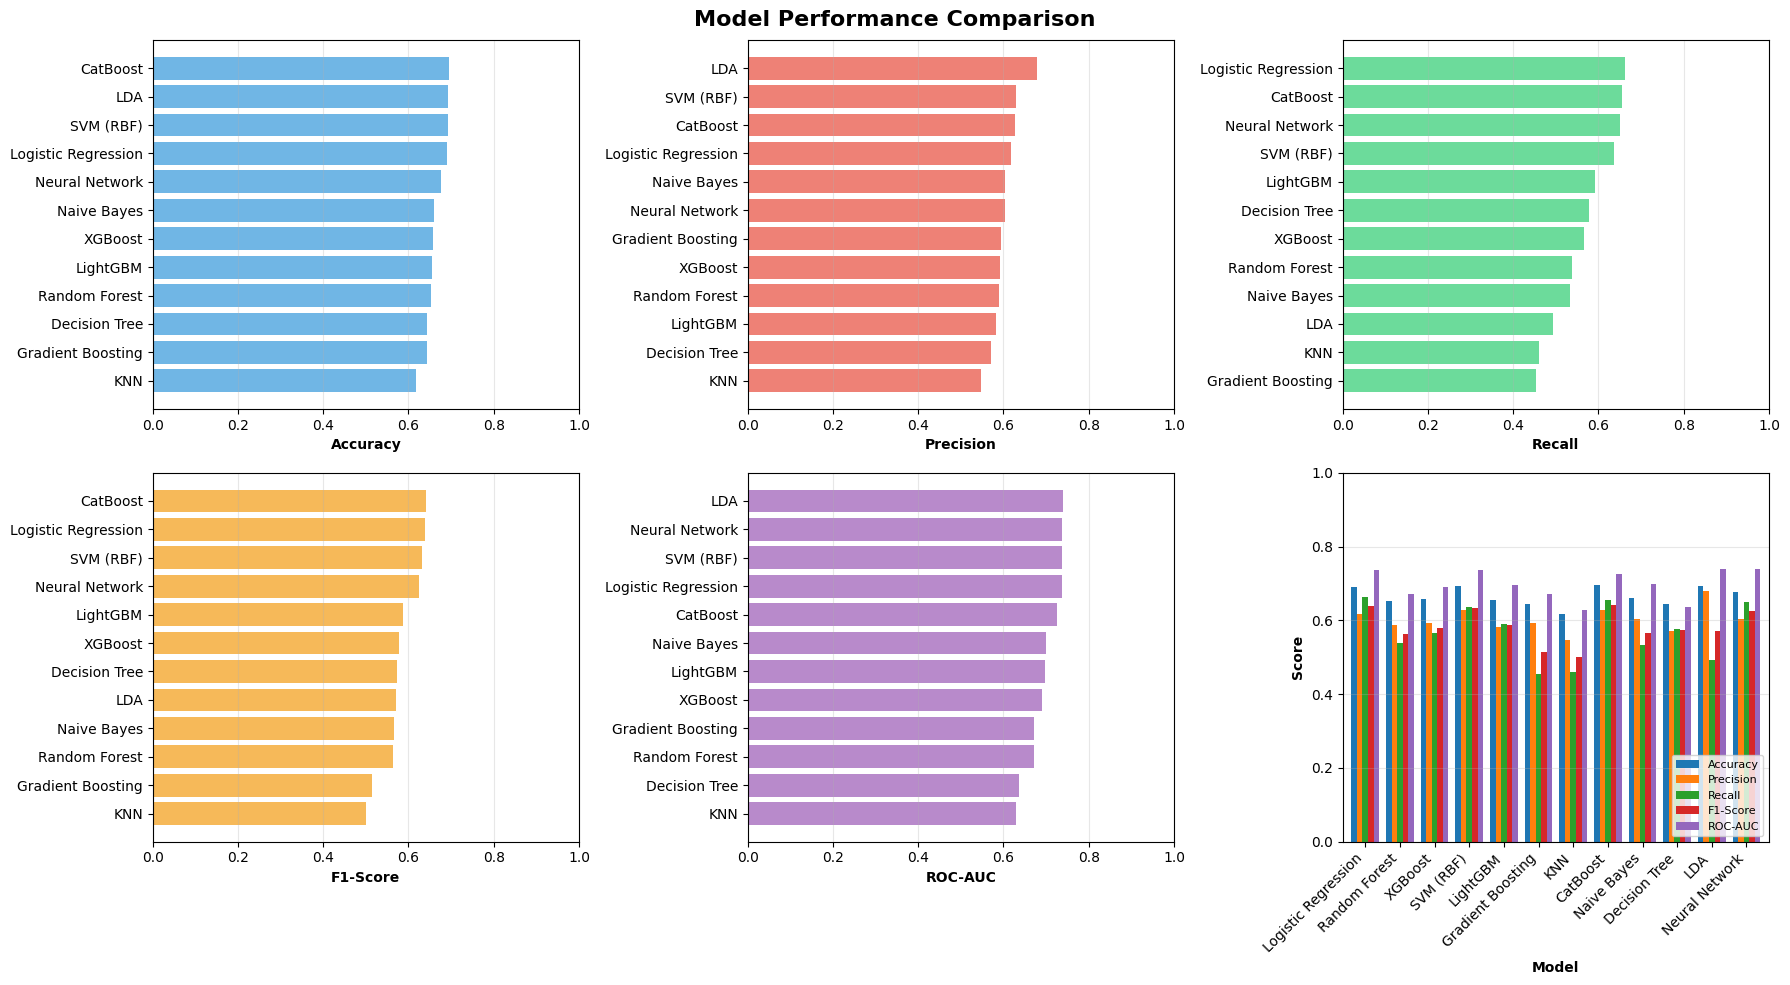


Analysis complete! Check the visualizations above.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import all models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from tensorflow import keras
import tensorflow as tf

# Select features
selected_features = [
    'Child Age', 'Fever', 'Household Size', 'Mother Anemia',
    'Parasite Deworm', 'Amenorrhea', 'Ethnicity_Hill Janajati',
    'Ethnicity_Other', 'Province_Koshi', 'Province_Madhesh province'
]

X_selected = X_encoded[selected_features]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

# Scale data for models that need it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Storage for results
results_list = []

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """Train and evaluate a model"""
    print(f"\nTraining {model_name}...")
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    results = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba)
    }
    
    print(f"  Accuracy: {results['Accuracy']:.4f} | F1-Score: {results['F1-Score']:.4f} | ROC-AUC: {results['ROC-AUC']:.4f}")
    
    return results

# Define all models
print("="*80)
print("AUTOMATED MODEL COMPARISON")
print("="*80)

# 1. Logistic Regression
model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
results_list.append(evaluate_model(model, X_train, X_test, y_train, y_test, 'Logistic Regression'))

# 2. Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', 
                                max_depth=10, n_jobs=-1)
results_list.append(evaluate_model(model, X_train, X_test, y_train, y_test, 'Random Forest'))

# 3. XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
model = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42,
                      scale_pos_weight=scale_pos_weight, eval_metric='logloss', use_label_encoder=False)
results_list.append(evaluate_model(model, X_train, X_test, y_train, y_test, 'XGBoost'))

# 4. SVM (RBF) - needs scaled data
model = SVC(kernel='rbf', C=1.0, random_state=42, class_weight='balanced', probability=True)
results_list.append(evaluate_model(model, X_train_scaled, X_test_scaled, y_train, y_test, 'SVM (RBF)'))

# 5. LightGBM
model = LGBMClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42,
                       class_weight='balanced', verbose=-1)
results_list.append(evaluate_model(model, X_train, X_test, y_train, y_test, 'LightGBM'))

# 6. Gradient Boosting
model = GradientBoostingClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, 
                                   random_state=42, subsample=0.8)
results_list.append(evaluate_model(model, X_train, X_test, y_train, y_test, 'Gradient Boosting'))

# 7. KNN - needs scaled data
model = KNeighborsClassifier(n_neighbors=5, weights='distance', n_jobs=-1)
results_list.append(evaluate_model(model, X_train_scaled, X_test_scaled, y_train, y_test, 'KNN'))

# 8. CatBoost
model = CatBoostClassifier(iterations=100, depth=5, learning_rate=0.1, random_state=42,
                           auto_class_weights='Balanced', verbose=0)
results_list.append(evaluate_model(model, X_train, X_test, y_train, y_test, 'CatBoost'))

# 9. Naive Bayes
model = GaussianNB()
results_list.append(evaluate_model(model, X_train, X_test, y_train, y_test, 'Naive Bayes'))

# 10. Decision Tree
model = DecisionTreeClassifier(max_depth=10, min_samples_split=10, random_state=42, 
                                class_weight='balanced')
results_list.append(evaluate_model(model, X_train, X_test, y_train, y_test, 'Decision Tree'))

# 11. LDA
model = LinearDiscriminantAnalysis()
results_list.append(evaluate_model(model, X_train, X_test, y_train, y_test, 'LDA'))

# 12. Neural Network - needs scaled data
print(f"\nTraining Neural Network...")
class_weight = {0: 1.0, 1: (y_train == 0).sum() / (y_train == 1).sum()}
nn_model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(10,)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation='sigmoid')
])
nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
nn_model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2,
             class_weight=class_weight, verbose=0)
y_pred_proba = nn_model.predict(X_test_scaled, verbose=0).flatten()
y_pred = (y_pred_proba > 0.5).astype(int)
results_list.append({
    'Model': 'Neural Network',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-Score': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba)
})
print(f"  Accuracy: {results_list[-1]['Accuracy']:.4f} | F1-Score: {results_list[-1]['F1-Score']:.4f} | ROC-AUC: {results_list[-1]['ROC-AUC']:.4f}")

# Create comparison DataFrame
comparison_df = pd.DataFrame(results_list)

# Display results
print("\n" + "="*100)
print("COMPLETE MODEL COMPARISON RESULTS")
print("="*100)
print(comparison_df.to_string(index=False))

# Best models
print("\n" + "="*100)
print("BEST PERFORMING MODELS")
print("="*100)
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']:
    best_idx = comparison_df[metric].idxmax()
    print(f"Best {metric:10s}: {comparison_df.loc[best_idx, 'Model']:20s} ({comparison_df.loc[best_idx, metric]:.4f})")

# Ranking by F1-Score
print("\n" + "="*100)
print("RANKING BY F1-SCORE")
print("="*100)
comparison_sorted = comparison_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)
comparison_sorted.index = comparison_sorted.index + 1
print(comparison_sorted.to_string())

# Visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for idx, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    ax = axes[idx // 3, idx % 3]
    sorted_data = comparison_df.sort_values(metric, ascending=True)
    ax.barh(sorted_data['Model'], sorted_data[metric], color=color, alpha=0.7)
    ax.set_xlabel(metric, fontweight='bold')
    ax.set_xlim([0, 1])
    ax.grid(axis='x', alpha=0.3)
    
# Overall comparison
ax = axes[1, 2]
comparison_df_plot = comparison_df.set_index('Model')[metrics_to_plot]
comparison_df_plot.plot(kind='bar', ax=ax, width=0.8)
ax.set_ylabel('Score', fontweight='bold')
ax.set_xlabel('Model', fontweight='bold')
ax.legend(loc='lower right', fontsize=8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*100)
print("Analysis complete! Check the visualizations above.")
print("="*100)

### PCA

In [ ]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print('Number of PCA components selected:', pca.n_components_)

Number of PCA components selected: 2


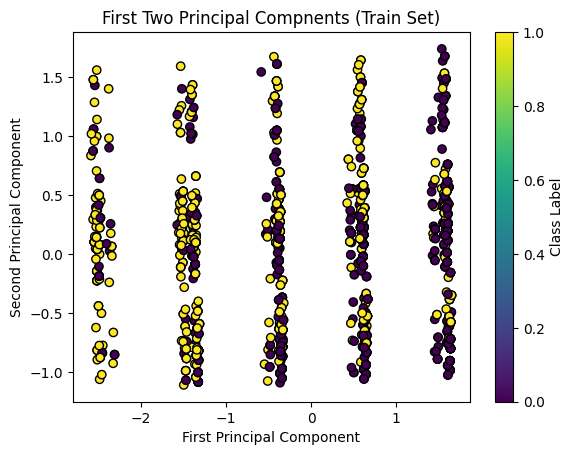

In [ ]:
plt.scatter(X_train_pca[:, 0], X_train_pca[:,1], c=y_train, edgecolor='k')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('First Two Principal Compnents (Train Set)')
plt.colorbar(label='Class Label')
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
pca = KNeighborsClassifier()
pca.fit(X_train_pca, y_train)
y_pred = pca.predict(X_test_pca)

# Evaluation Metrics
accu = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print
print('Accuracy using PCA:', accu)
print('Precision using PCA:', precision)
print('Recall using PCA:', recall)
print('F1-scorer using PCA:', f1)

Accuracy using PCA: 0.6307277628032345
Precision using PCA: 0.6227444253859348
Recall using PCA: 0.6307277628032345
F1-scorer using PCA: 0.6216185204638196


## SVD

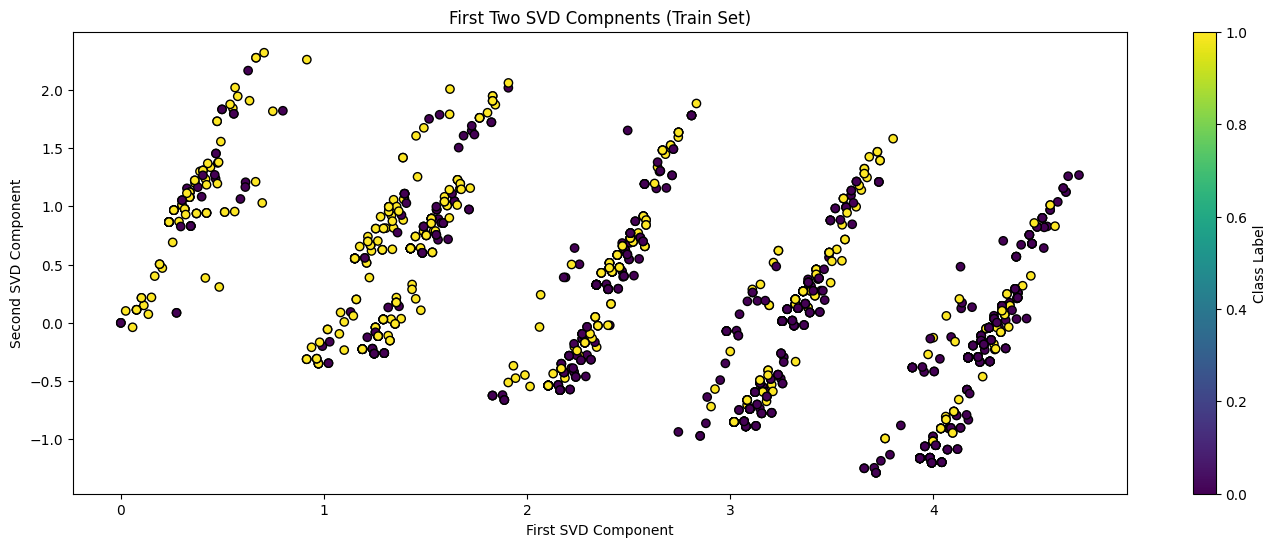

In [ ]:
svd = TruncatedSVD(n_components=7, random_state=42)
X_train_svd = svd.fit_transform(X_train)
X_test_svd = svd.transform(X_test)

plt.figure(figsize=(17,6))
plt.scatter(X_train_svd[:, 0], X_train_svd[:,1], c=y_train, edgecolor='k')
plt.xlabel('First SVD Component')
plt.ylabel('Second SVD Component')
plt.title('First Two SVD Compnents (Train Set)')
plt.colorbar(label='Class Label')
plt.show()